In [1]:
import pandas as pd

df = pd.read_csv('apples_and_oranges.csv')
df

,Weight,Size,Class
0,69,4.39,orange
1,69,4.21,orange
2,65,4.09,orange
3,72,5.85,apple
4,67,4.70,orange
5,73,5.68,apple
6,70,5.56,apple
7,75,5.11,apple
8,74,5.36,apple
9,65,4.27,orange


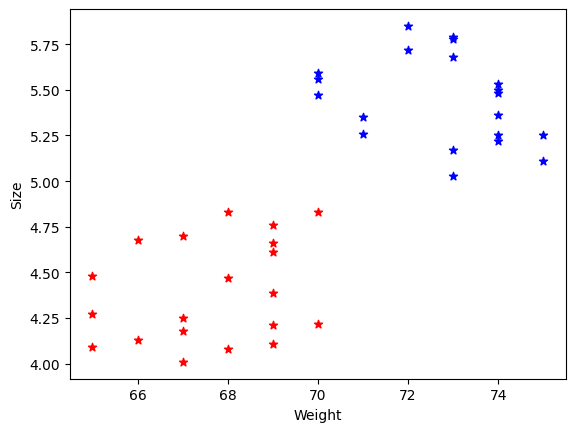

In [2]:
import matplotlib.pyplot as plt

plt.xlabel('Weight')
plt.ylabel('Size')

dforange = df.query("Class =='orange'")

dfapple = df.query("Class =='apple'")

plt.scatter(dforange['Weight'], dforange['Size'], color="red", marker='*')
plt.scatter(dfapple['Weight'], dfapple['Size'], color="blue", marker='*')

In [3]:
from sklearn.model_selection import train_test_split

X = df[['Weight','Size']]
y = df['Class']

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y)

from sklearn.svm import SVC

model = SVC(kernel='linear')

model.fit(X_train.values, y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [4]:
y_pred=model.predict(X_test.values)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print('\nAccuracy: {:.2f}\n'.format(100*accuracy_score(y_test, y_pred)))

print('\nPrecision: {:.2f}\n'.format(100*precision_score(y_test, y_pred)))

print('\nRecall: {:.2f}\n'.format(100*recall_score(y_test, y_pred)))

print('\nF1: {:.2f}\n'.format(100*f1_score(y_test, y_pred)))


Accuracy: 100.00


Precision: 100.00


Recall: 100.00


F1: 100.00



In [5]:
Weight=62
Size=3

Classpred = model.predict([[Weight,Size]])

Classpred = le.inverse_transform(Classpred)
print(Classpred)

['orange']


In [6]:
Weight=74
Size=5.3

Classpred = model.predict([[Weight,Size]])
Classpred = le.inverse_transform(Classpred)
print(Classpred)

['apple']
